In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

In [17]:
b = pd.read_csv(
    Path.cwd().parent / 'results' / 'csvs_3_latest' / 'nodal_energy_balance.csv', index_col=[0,1,2,3], header=list(range(5))
    )
p = pd.read_csv(
    Path.cwd().parent / 'results' / 'csvs_3_latest' / 'weighted_prices.csv', index_col=[0], header=list(range(5))
    )
c = pd.read_csv(
    Path.cwd().parent / 'results' / 'csvs_3_latest' / 'nodal_capacity_factors.csv', index_col=[0,1,2], header=list(range(5))
    )

In [18]:
c.head()

cluster                                                     50            \
opt                                         3H-T-H-B-I-A-dist1             
planning_horizon                                          2035             
tyndp_scenario                                            free             
wiggle                                                       0       250   
component location carrier                                                 
Generator AL0 0    Offshore Wind (AC)                 0.118687  0.121212   
                   Offshore Wind (Floating)           0.141509  0.144444   
                   Onshore Wind                       0.037705  0.037030   
                   Run of River                       0.483454  0.506577   
                   Solar                              0.112789  0.166410   

cluster                                                                    \
opt                                                                         
planning_horizon                                                            
tyndp_scenario                                                              
wiggle                                            500       750      1000   
component location carrier                                                  
Generator AL0 0    Offshore Wind (AC)        0.119171  0.121019  0.118026   
                   Offshore Wind (Floating)  0.148148  0.142857  0.142582   
                   Onshore Wind              0.037080  0.037479  0.038523   
                   Run of River              0.506587  0.507921  0.494844   
                   Solar                     0.147372  0.084875  0.097054   

cluster                                                                    \
opt                                                                         
planning_horizon                                                            
tyndp_scenario                                                              
wiggle                                           1250      1500      1750   
component location carrier                                                  
Generator AL0 0    Offshore Wind (AC)        0.114286  0.115556       NaN   
                   Offshore Wind (Floating)  0.144578  0.141791       NaN   
                   Onshore Wind              0.037777  0.037914  0.037426   
                   Run of River              0.508790  0.508354  0.511569   
                   Solar                     0.088754  0.167971  0.171402   

cluster                                                                    \
opt                                                                         
planning_horizon                                                            
tyndp_scenario                                                              
wiggle                                           2000      2250      2500   
component location carrier                                                  
Generator AL0 0    Offshore Wind (AC)        0.113043  0.114806  0.112717   
                   Offshore Wind (Floating)  0.148649  0.143742  0.140351   
                   Onshore Wind              0.038545  0.040081  0.039892   
                   Run of River              0.508598  0.500720  0.508512   
                   Solar                     0.123776  0.136908  0.155764   

cluster                                                                    \
opt                                                                         
planning_horizon                                                            
tyndp_scenario                                                              
wiggle                                           2750      3000      3250   
component location carrier                                                  
Generator AL0 0    Offshore Wind (AC)        0.113131  0.112150  0.106557   
                   Offshore Wind (Floating)  0.141705  0.138211  0.139535   
   

In [27]:
def find_transition_column(
    df: pd.DataFrame,
    *,
    heuristic: str = "peak_slope",     # "peak_slope" | "first_nonzero"
    min_rel_change: float = 0.5,       # return NaN if row range < min_rel_change * row_max
    zero_tol: float = 0.0,             # used for "first_nonzero"
    direction: str = "upward",         # "upward" | "downward"
) -> pd.Series:
    """
    For each row in df, return the column label where the *transition* occurs.

    Parameters
    ----------
    df : pd.DataFrame
        Rows to analyze.
    heuristic : str
        "peak_slope": pick the column where the extreme slope is maximal in the chosen direction.
        "first_nonzero": pick the first column where the row value becomes non-zero ( > zero_tol ).
    min_rel_change : float
        If row value range < min_rel_change * row_max, treat as constant and return NaN.
    zero_tol : float
        Used for "first_nonzero".
    direction : str
        "upward" (default): look for maximal increase.
        "downward": look for maximal decrease.

    Special cases:
    - If a row does not change by at least `min_rel_change` of its own max value,
      return NaN (i.e. approximately constant rows).
    - If there is no slope of the desired direction, return NaN.

    Returns
    -------
    pd.Series
        Index = df.index (row names), values = df.columns label (can be MultiIndex value) or NaN.
    """
    if heuristic not in {"peak_slope", "first_nonzero"}:
        raise ValueError("heuristic must be one of {'peak_slope', 'first_nonzero'}")
    if direction not in {"upward", "downward"}:
        raise ValueError("direction must be one of {'upward', 'downward'}")

    cols = df.columns
    out = []

    for _, row in df.iterrows():
        x = row.to_numpy(dtype=float)

        # robust-ish NaN handling
        if np.all(np.isnan(x)):
            out.append(np.nan)
            continue

        row_max = np.nanmax(x)
        row_min = np.nanmin(x)

        # constant-ish rows (or all-zero rows)
        if not np.isfinite(row_max) or row_max <= 0:
            out.append(np.nan)
            continue
        if (row_max - row_min) < (min_rel_change * row_max):
            out.append(np.nan)
            continue

        if heuristic == "first_nonzero":
            mask = x > zero_tol
            if not np.any(mask):
                out.append(np.nan)
            else:
                j = int(np.argmax(mask))  # first True
                out.append(cols[j])
            continue

        # heuristic == "peak_slope"
        if len(x) < 2:
            out.append(np.nan)
            continue

        d = np.diff(x)
        if direction == "upward":
            d_target = np.where(d > 0, d, -np.inf)  # ignore downward/flat slopes
            check_fn = lambda val: np.isfinite(val) and val > 0
        else:  # direction == "downward"
            d_target = np.where(d < 0, d, np.inf)   # ignore upward/flat slopes
            check_fn = lambda val: np.isfinite(val) and val < 0

        if not np.any(np.isfinite(d_target)):
            out.append(np.nan)
            continue

        # For upward: take max; for downward: take min
        if direction == "upward":
            j = int(np.nanargmax(d_target))
        else:
            j = int(np.nanargmin(d_target))
        if not check_fn(d_target[j]):
            out.append(np.nan)
        else:
            # diff between cols[j] -> cols[j+1]; return the "arrival" column
            out.append(cols[j + 1])

    return pd.Series(out, index=df.index, name="transition_column").dropna().astype(int)

In [23]:
b.columns = b.columns.get_level_values(-1)

<Axes: xlabel='wiggle'>

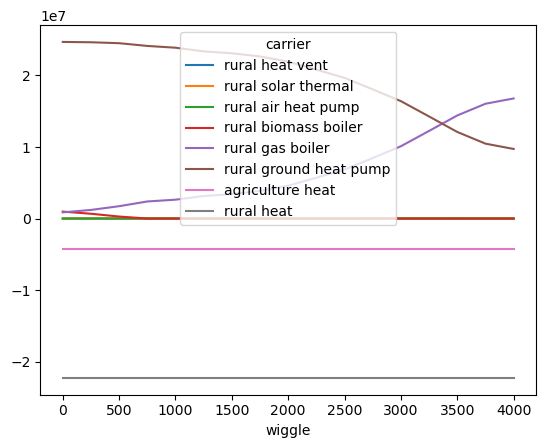

In [26]:
idx = pd.IndexSlice

ss = b.loc[idx[:,:,'DE0 0','rural heat']]
ss.index = ss.index.droplevel(0)
ss.T.plot()

carrier
rural ground heat pump    3250
Name: transition_column, dtype: int64
carrier
rural ground heat pump    2250
Name: transition_column, dtype: int64
Series([], Name: transition_column, dtype: int64)


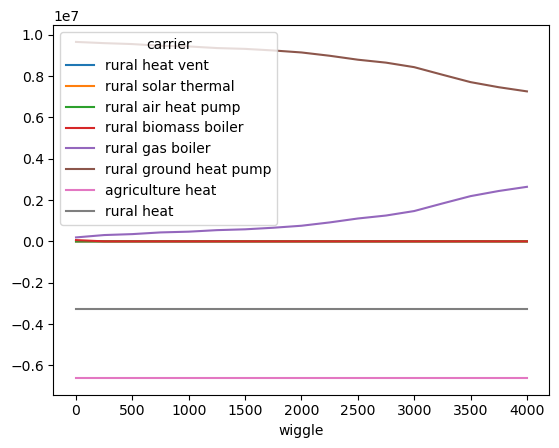

In [50]:
buses = b.index.get_level_values(2).unique()
ghps = pd.Series(np.nan, index=buses)

for bus in buses:

    ss = b.loc[idx[:, :, bus, 'rural heat']]
    ss.index = ss.index.droplevel(0)
    # print(ss.loc[['rural ground heat pump']])

    try:
        # print(bus, ss.loc[['rural ground heat pump']])
        value = find_transition_column(ss.loc[['rural ground heat pump']], direction='downward')
        print(value)

        if value.empty:

            ss.T.plot()
            break

        print('===================')
        # ghps.loc[bus] = find_transition_column(ss.loc[['rural ground heat pump']], direction='downward')
    except KeyError:
        continue
ghps.dropna(inplace=True)

In [52]:
sss = ss.loc[['rural ground heat pump']]

In [ ]:
sss

wiggle,0,250,500,750,1000,1250,1500,1750,2000,2250,2500,2750,3000,3250,3500,3750,4000
carrier,,,,,,,,,,,,,,,,,
rural ground heat pump,9.652768e+06,9.593966e+06,9.548622e+06,9.466074e+06,9.433205e+06,9.355923e+06,9.315979e+06,9.239258e+06,9.142701e+06,8.983144e+06,8.792313e+06,8.649888e+06,8.431328e+06,8.065101e+06,7.706766e+06,7.460457e+06,7.259088e+06


In [ ]:
for _, row in sss.iterrows():
    x = row.to_numpy(dtype=float)

    # robust-ish NaN handling
    if np.all(np.isnan(x)):
        out.append(np.nan)
        continue

    row_max = np.nanmax(x)
    row_min = np.nanmin(x)

    # constant-ish rows (or all-zero rows)
    if not np.isfinite(row_max) or row_max <= 0:
        out.append(np.nan)
        continue
    if (row_max - row_min) < (min_rel_change * row_max):
        out.append(np.nan)
        continue

    if heuristic == "first_nonzero":
        mask = x > zero_tol
        if not np.any(mask):
            out.append(np.nan)
        else:
            j = int(np.argmax(mask))  # first True
            out.append(cols[j])
        continue